# IEEE-CIS fraud detection
# Hahn

**任务**: 基于IEEE-CIS数据集检测欺诈交易，预测每笔交易的欺诈概率。

**技术路线**:
1. 数据预处理：缺失值处理、V列降维(339列→NaN分组+相关性剔除自动选取)、PCA/t-SNE可视化
2. 特征工程：频率编码（含时间块）、标签编码（类别型特征 → 整数）、聚合特征、特征组合、UID特征
3. 模型训练：逻辑回归、SVM、XGBoost三模型对比
4. 评估指标：AUC、F1、Accuracy、RMSE

In [ ]:
import subprocess
subprocess.run(['apt-get', 'install', '-y', 'fonts-noto-cjk'], capture_output=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.font_manager as fm
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import GroupKFold
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, mean_squared_error
import xgboost as xgb
for font_path in fm.findSystemFonts():
    if 'NotoSansCJK' in font_path or 'NotoSerifCJK' in font_path or 'noto' in font_path.lower():
        fm.fontManager.addfont(font_path)

matplotlib.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Noto Sans CJK JP', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = [12, 5]

pd.set_option('display.max_columns', 50)

import os
_fig_counter = [0]
_orig_show = plt.show
def _auto_save_show():
    _fig_counter[0] += 1
    plt.savefig(f'/kaggle/working/fig_{_fig_counter[0]:02d}.png', dpi=150, bbox_inches='tight')
    _orig_show()
plt.show = _auto_save_show

print(f'库加载完成！XGBoost {xgb.__version__}')
print('图片将自动保存到 /kaggle/working/fig_XX.png')

库加载完成！XGBoost 3.2.0
图片将自动保存到 /kaggle/working/fig_XX.png


---
## 一、数据加载

In [ ]:
#V列全集定义（自动降维分析将在EDA阶段执行，见下方cell-9）
v_all_names = ['V' + str(i) for i in range(1, 340)]
print(f'V列总数: {len(v_all_names)} 列，将通过NaN模式分组 + 相关性剔除自动降维')

V列总数: 339 列，将通过NaN模式分组 + 相关性剔除自动降维


In [ ]:
%%time
import os

#自动检测运行环境，设置数据路径
if os.path.exists('/kaggle/input/ieee-fraud-detection/'):
    DATA_PATH = '/kaggle/input/ieee-fraud-detection/'
elif os.path.exists('/kaggle/input/competitions/ieee-fraud-detection/'):
    DATA_PATH = '/kaggle/input/competitions/ieee-fraud-detection/'
else:
    DATA_PATH = 'ieee-fraud-detection/'
print(f'数据路径: {DATA_PATH}')

#加载训练数据
print('正在加载训练集...')
X_train = pd.read_csv(DATA_PATH + 'train_transaction.csv', index_col='TransactionID')
train_id = pd.read_csv(DATA_PATH + 'train_identity.csv', index_col='TransactionID')
train_id_cols = train_id.columns.tolist()
X_train = X_train.merge(train_id, how='left', left_index=True, right_index=True)
y_train = X_train['isFraud'].copy()
X_train.drop('isFraud', axis=1, inplace=True)
del train_id; gc.collect()

#加载测试数据
print('正在加载测试集...')
X_test = pd.read_csv(DATA_PATH + 'test_transaction.csv', index_col='TransactionID')
test_id = pd.read_csv(DATA_PATH + 'test_identity.csv', index_col='TransactionID')
col_fix = {o: n for o, n in zip(test_id.columns, train_id_cols)}
test_id.rename(columns=col_fix, inplace=True)
X_test = X_test.merge(test_id, how='left', left_index=True, right_index=True)
del test_id, train_id_cols, col_fix; gc.collect()

print(f'训练集: {X_train.shape}')
print(f'测试集:  {X_test.shape}')
print(f'欺诈比例: {y_train.mean():.4%}')

数据路径: /kaggle/input/competitions/ieee-fraud-detection/
正在加载训练集...
正在加载测试集...
训练集: (590540, 432)
测试集:  (506691, 432)
欺诈比例: 3.4990%
CPU times: user 33.7 s, sys: 5.7 s, total: 39.4 s
Wall time: 47.9 s


---
## 二、探索性数据分析（EDA）

In [ ]:
#基本信息概览
print('=' * 55)
print(f'训练集样本数:  {X_train.shape[0]:>10,}')
print(f'训练集特征数:  {X_train.shape[1]:>10,}')
print(f'测试集样本数:  {X_test.shape[0]:>10,}')
print('=' * 55)
fraud_counts = y_train.value_counts()
print(f"正常交易(0): {fraud_counts[0]:>8,}  ({fraud_counts[0]/len(y_train):.2%})")
print(f"欺诈交易(1): {fraud_counts[1]:>8,}  ({fraud_counts[1]/len(y_train):.2%})")
print('=' * 55)
#数值型vs类别型特征
num_feats = X_train.select_dtypes(include=[np.number]).shape[1]
cat_feats = X_train.select_dtypes(exclude=[np.number]).shape[1]
print(f'数值型特征: {num_feats}, 类别型特征: {cat_feats}')

训练集样本数:     590,540
训练集特征数:         432
测试集样本数:     506,691
正常交易(0):  569,877  (96.50%)
欺诈交易(1):   20,663  (3.50%)
数值型特征: 401, 类别型特征: 31


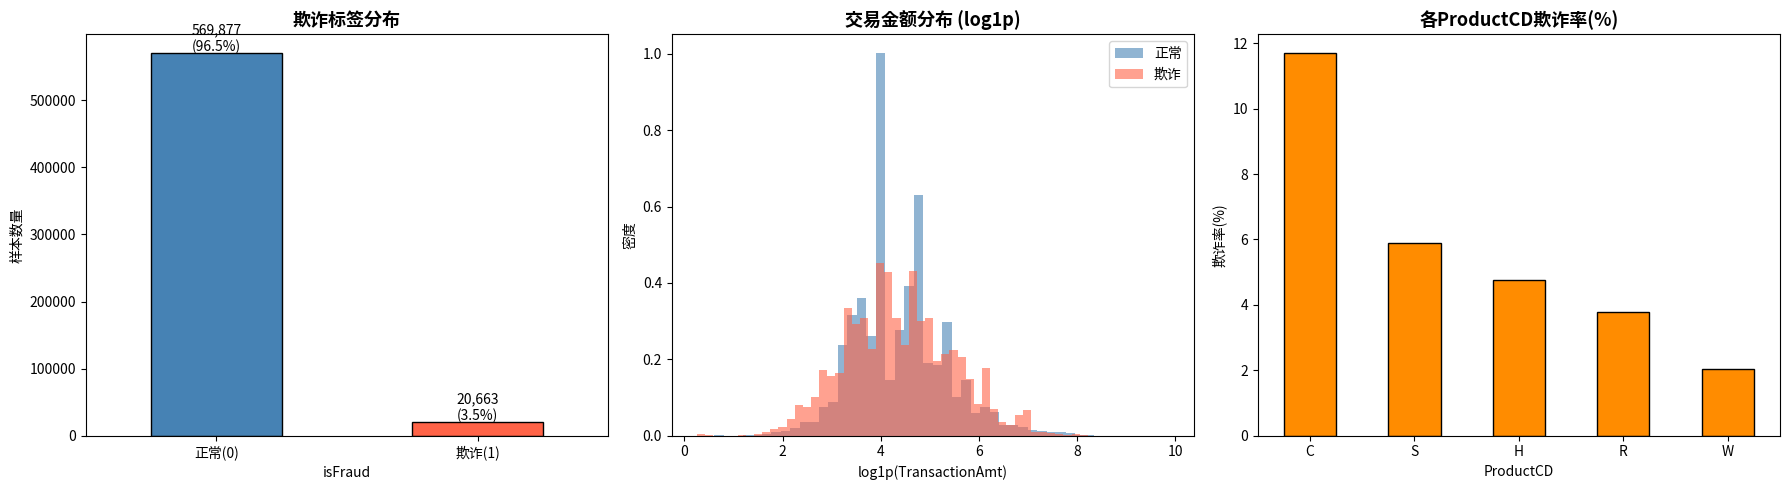

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#图1：目标变量分布
ax = axes[0]
fraud_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
ax.set_title('欺诈标签分布', fontsize=13, fontweight='bold')
ax.set_xticklabels(['正常(0)', '欺诈(1)'], rotation=0)
ax.set_ylabel('样本数量')
for i, v in enumerate(fraud_counts):
    ax.text(i, v + 3000, f'{v:,}\n({v/len(y_train):.1%})', ha='center', fontsize=10)

#图2：交易金额分布（正常 vs 欺诈）
ax = axes[1]
bins = np.linspace(0, 10, 60)
ax.hist(np.log1p(X_train.loc[y_train==0, 'TransactionAmt'].clip(upper=20000)),
        bins=50, alpha=0.6, label='正常', color='steelblue', density=True)
ax.hist(np.log1p(X_train.loc[y_train==1, 'TransactionAmt'].clip(upper=20000)),
        bins=50, alpha=0.6, label='欺诈', color='tomato', density=True)
ax.set_title('交易金额分布 (log1p)', fontsize=13, fontweight='bold')
ax.set_xlabel('log1p(TransactionAmt)')
ax.set_ylabel('密度')
ax.legend()

#图3：ProductCD 欺诈率
ax = axes[2]
prod_fraud = pd.DataFrame({'total': X_train['ProductCD'].value_counts(),
                            'fraud': X_train.loc[y_train==1, 'ProductCD'].value_counts()})
prod_fraud['rate'] = prod_fraud['fraud'] / prod_fraud['total'] * 100
prod_fraud['rate'].sort_values(ascending=False).plot(kind='bar', ax=ax,
                                                      color='darkorange', edgecolor='black')
ax.set_title('各ProductCD欺诈率(%)', fontsize=13, fontweight='bold')
ax.set_ylabel('欺诈率(%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

有缺失值的特征数: 414 / 432

缺失率区间分布:
    0%- 10%:  92 个特征
   10%- 30%:  90 个特征
   30%- 50%:  18 个特征
   50%- 80%: 140 个特征
   80%-100%:  74 个特征


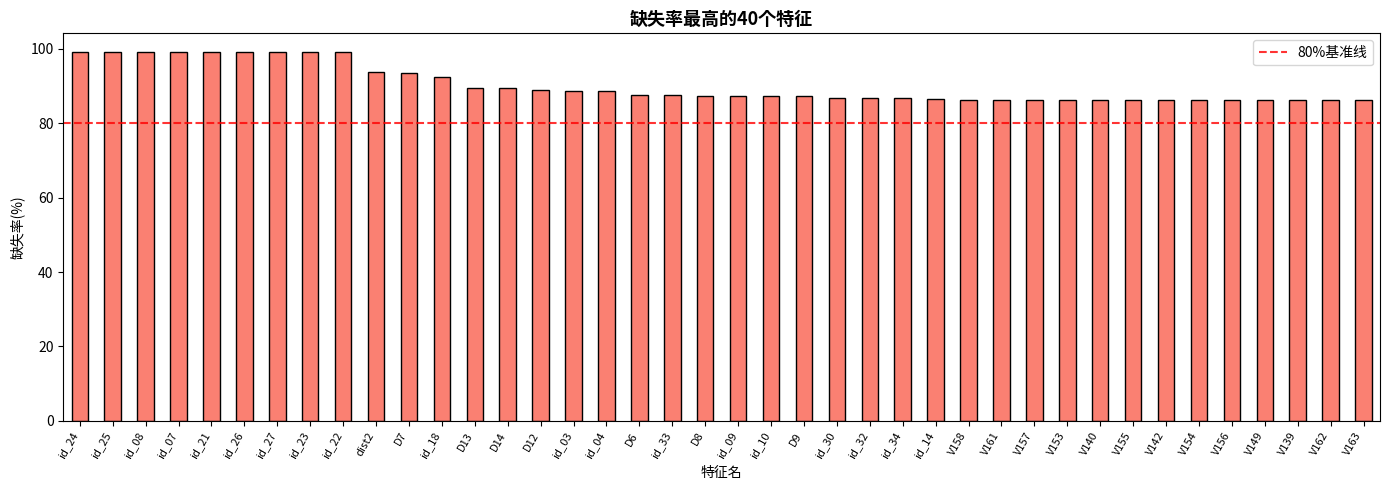

In [ ]:
#缺失值分析
missing_pct = (X_train.isnull().sum() / len(X_train) * 100).sort_values(ascending=False)
missing_any = missing_pct[missing_pct > 0]

print(f'有缺失值的特征数: {len(missing_any)} / {X_train.shape[1]}')
print(f'\n缺失率区间分布:')
for lo, hi in [(0,10),(10,30),(30,50),(50,80),(80,100)]:
    cnt = ((missing_any > lo) & (missing_any <= hi)).sum()
    print(f'  {lo:3d}%-{hi:3d}%: {cnt:3d} 个特征')

fig, ax = plt.subplots(figsize=(14, 5))
missing_any.head(40).plot(kind='bar', ax=ax, color='salmon', edgecolor='black')
ax.axhline(y=80, color='red', linestyle='--', alpha=0.8, label='80%基准线')
ax.set_title('缺失率最高的40个特征', fontsize=13, fontweight='bold')
ax.set_xlabel('特征名')
ax.set_ylabel('缺失率(%)')
ax.legend()
plt.xticks(rotation=60, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
#V列NaN模式分析 + 分组聚合
#同组内列高度相关但并非完全冗余，聚合比只取一列信息更完整

#Step 1: 按NaN数量分组
nans_count = X_train[v_all_names].isnull().sum()
nan_groups = {}
for col in v_all_names:
    key = int(nans_count[col])
    nan_groups.setdefault(key, []).append(col)

print(f'V列NaN模式分组（共 {len(nan_groups)} 种缺失模式）:')
for k in sorted(nan_groups.keys()):
    v = nan_groups[k]
    print(f'  NaN数={k:,}: {len(v):2d}列  {v[:4]}{"..." if len(v)>4 else ""}')

#Step 2: 对每个NaN组创建聚合特征 sum / mean / std
print(f'\n创建分组聚合特征...')
group_feat_names = []
for i, (nan_count, cols) in enumerate(sorted(nan_groups.items())):
    for df in [X_train, X_test]:
        sub = df[cols]
        df[f'V_grp{i}_sum']  = sub.sum(axis=1).astype('float32')
        df[f'V_grp{i}_mean'] = sub.mean(axis=1).astype('float32')
        df[f'V_grp{i}_std']  = sub.std(axis=1).fillna(0).astype('float32')
    group_feat_names.extend([f'V_grp{i}_sum', f'V_grp{i}_mean', f'V_grp{i}_std'])

print(f'完成: {len(nan_groups)} 组 × 3 = {len(group_feat_names)} 个聚合特征')
print(f'（下一步删除全部339个原始V列）')

V列NaN模式分组（共 15 种缺失模式）:
  NaN数=12: 32列  ['V279', 'V280', 'V284', 'V285']...
  NaN数=314: 43列  ['V95', 'V96', 'V97', 'V98']...
  NaN数=1,269: 11列  ['V281', 'V282', 'V283', 'V288']...
  NaN数=76,073: 23列  ['V12', 'V13', 'V14', 'V15']...
  NaN数=77,096: 22列  ['V53', 'V54', 'V55', 'V56']...
  NaN数=89,164: 20列  ['V75', 'V76', 'V77', 'V78']...
  NaN数=168,969: 18列  ['V35', 'V36', 'V37', 'V38']...
  NaN数=279,287: 11列  ['V1', 'V2', 'V3', 'V4']...
  NaN数=449,124: 16列  ['V220', 'V221', 'V222', 'V227']...
  NaN数=450,721: 19列  ['V169', 'V170', 'V171', 'V174']...
  NaN数=450,909: 31列  ['V167', 'V168', 'V172', 'V173']...
  NaN数=460,110: 46列  ['V217', 'V218', 'V219', 'V223']...
  NaN数=508,189: 18列  ['V322', 'V323', 'V324', 'V325']...
  NaN数=508,589: 11列  ['V143', 'V144', 'V145', 'V150']...
  NaN数=508,595: 18列  ['V138', 'V139', 'V140', 'V141']...

创建分组聚合特征...
完成: 15 组 × 3 = 45 个聚合特征
（下一步删除全部339个原始V列）


---
## 三、数据预处理

In [ ]:
#3.1 V列处理：删除全部339个原始V列，保留分组聚合特征
X_train.drop(columns=[c for c in v_all_names if c in X_train.columns], inplace=True)
X_test.drop(columns=[c for c in v_all_names if c in X_test.columns], inplace=True)
gc.collect()
print(f'原始V列已全部删除（339列）')
print(f'保留分组聚合特征: {len(group_feat_names)} 列')
print(f'训练集当前维度: {X_train.shape}')

原始V列已全部删除（339列）
保留分组聚合特征: 45 列
训练集当前维度: (590540, 138)


In [ ]:
#3.2 时间特征 + 设备解析 + 缺失值处理
import datetime

#cents特征：交易金额的小数部分（必须在log1p之前计算，否则含义错误）
X_train['cents'] = (X_train['TransactionAmt'] % 1).astype('float32')
X_test['cents']  = (X_test['TransactionAmt']  % 1).astype('float32')

#TransactionAmt log1p变换（减小大额交易的量级差异，与17名解法一致）
X_train['TransactionAmt'] = np.log1p(X_train['TransactionAmt'])
X_test['TransactionAmt']  = np.log1p(X_test['TransactionAmt'])

#丰富时间特征（7个粒度）
for df in [X_train, X_test]:
    dt = pd.to_datetime(df['TransactionDT'], unit='s', origin=pd.Timestamp('2017-11-30'))
    df['DT_M']         = (df['TransactionDT'] // (86400 * 30)).astype('int8')   # 月
    df['DT_W']         = (df['TransactionDT'] // (86400 * 7)).astype('int16')   # 周
    df['DT_D']         = (df['TransactionDT'] // 86400).astype('int16')          # 天
    df['DT_hour']      = ((df['TransactionDT'] % 86400) // 3600).astype('int8') # 小时
    df['DT_day_week']  = dt.dt.dayofweek.astype('int8')                          # 星期几(0=周一)
    df['DT_day_month'] = dt.dt.day.astype('int8')                                # 月中第几天
    df['TransactionDay'] = df['DT_D']  # 兼容后续UID计算

#设备信息解析（提取设备类型字母部分 + 版本号数字部分）
for df in [X_train, X_test]:
    df['DeviceInfo'] = df['DeviceInfo'].fillna('unknown_device').str.lower()
    df['DeviceInfo_device']  = df['DeviceInfo'].apply(lambda x: ''.join([c for c in x if c.isalpha()]))
    df['DeviceInfo_version'] = df['DeviceInfo'].apply(lambda x: ''.join([c for c in x if c.isnumeric()]))

    for id_col in ['id_30', 'id_31']:
        if id_col in df.columns:
            df[id_col] = df[id_col].fillna('unknown').str.lower()
            df[id_col + '_device']  = df[id_col].apply(lambda x: ''.join([c for c in x if c.isalpha()]))
            df[id_col + '_version'] = df[id_col].apply(lambda x: ''.join([c for c in x if c.isnumeric()]))

#类别型特征
CAT_COLS = [c for c in [
    'ProductCD', 'card4', 'card6',
    'P_emaildomain', 'R_emaildomain',
    'M1','M2','M3','M4','M5','M6','M7','M8','M9',
    'id_12','id_15','id_16','id_23','id_27','id_28','id_29',
    'id_30','id_31','id_33','id_34','id_35','id_36','id_37','id_38',
    'DeviceType', 'DeviceInfo',
    'DeviceInfo_device', 'DeviceInfo_version',
    'id_30_device', 'id_30_version',
    'id_31_device', 'id_31_version',
] if c in X_train.columns]

for col in CAT_COLS:
    X_train[col].fillna('unknown', inplace=True)
    X_test[col].fillna('unknown', inplace=True)

for col in X_train.columns:
    if X_train[col].isnull().any():
        X_train[col].fillna(-1, inplace=True)
for col in X_test.columns:
    if X_test[col].isnull().any():
        X_test[col].fillna(-1, inplace=True)

remaining_na = X_train.isnull().sum().sum() + X_test.isnull().sum().sum()
print(f'缺失值处理完成! 剩余缺失值: {remaining_na}')
print(f'时间特征: DT_M/W/D/hour/day_week/day_month')
print(f'设备特征: DeviceInfo/id_30/id_31 → _device/_version')
print(f'TransactionAmt已做log1p变换')

缺失值处理完成! 剩余缺失值: 0
时间特征: DT_M/W/D/hour/day_week/day_month
设备特征: DeviceInfo/id_30/id_31 → _device/_version
TransactionAmt已做log1p变换


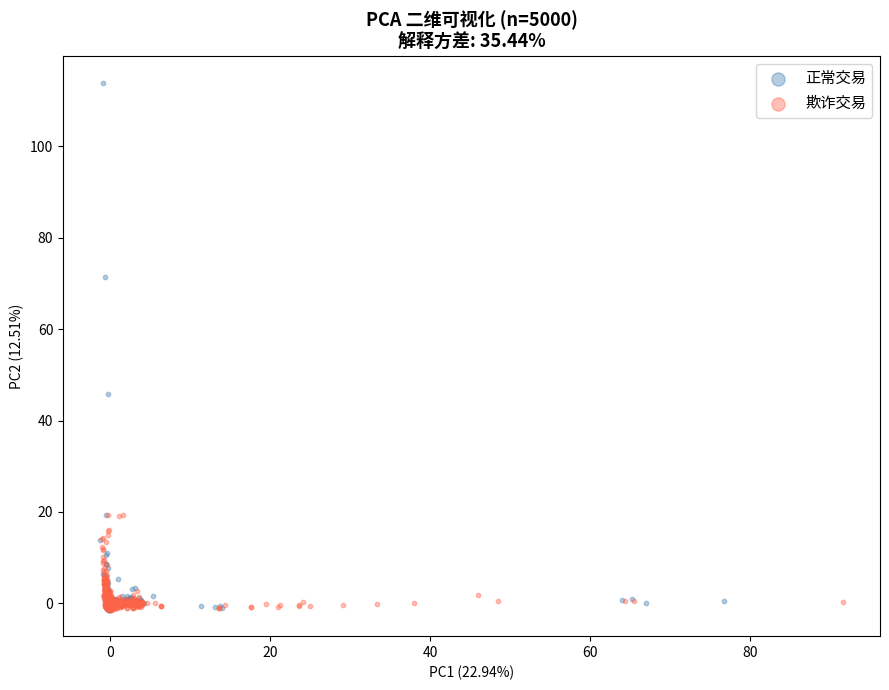

8579

In [ ]:
#3.3 PCA可视化（采样5000个样本）
N_PCA = 5000
np.random.seed(42)
fraud_idx  = y_train[y_train == 1].index
normal_idx = y_train[y_train == 0].index
sample_idx = np.concatenate([
    np.random.choice(normal_idx, N_PCA // 2, replace=False),
    np.random.choice(fraud_idx,  N_PCA // 2, replace=False)
])
y_sample = y_train.loc[sample_idx]

#使用V组聚合特征 + C列 + D列 + 金额
vis_feats = (
    ['TransactionAmt'] +
    [c for c in group_feat_names[:15] if c in X_train.columns] +
    ['C' + str(i) for i in range(1, 15) if 'C' + str(i) in X_train.columns] +
    ['D' + str(i) for i in range(1, 16) if 'D' + str(i) in X_train.columns]
)
X_vis = X_train.loc[sample_idx, vis_feats].fillna(0).copy()
X_vis_scaled = StandardScaler().fit_transform(X_vis)
pca = PCA(n_components=2, random_state=42)
X_pca2d = pca.fit_transform(X_vis_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for label, color, name in zip([0, 1], ['steelblue', 'tomato'], ['正常交易', '欺诈交易']):
    mask = y_sample.values == label
    ax.scatter(X_pca2d[mask, 0], X_pca2d[mask, 1], c=color, label=name, alpha=0.4, s=10)
explained = pca.explained_variance_ratio_
ax.set_title(f'PCA 二维可视化 (n={N_PCA})\n解释方差: {explained.sum():.2%}', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({explained[0]:.2%})')
ax.set_ylabel(f'PC2 ({explained[1]:.2%})')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.show()
del X_vis, X_vis_scaled; gc.collect()

正在运行t-SNE（约需1~3分钟）...


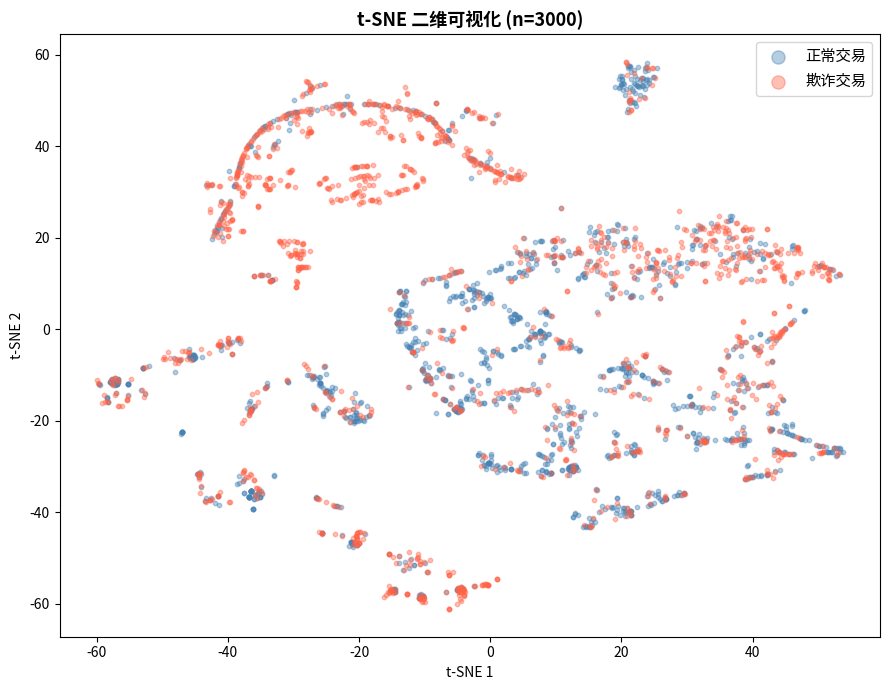

3408

In [ ]:
#3.4 t-SNE可视化（采样3000个样本）
N_TSNE = 3000
tsne_idx = np.concatenate([
    np.random.choice(normal_idx, N_TSNE // 2, replace=False),
    np.random.choice(fraud_idx,  N_TSNE // 2, replace=False)
])
y_tsne = y_train.loc[tsne_idx]

tsne_feats = (
    ['TransactionAmt'] +
    [c for c in group_feat_names[:10] if c in X_train.columns] +
    ['C' + str(i) for i in range(1, 10) if 'C' + str(i) in X_train.columns]
)
X_tsne = X_train.loc[tsne_idx, tsne_feats].fillna(0).copy()
X_tsne_scaled = StandardScaler().fit_transform(X_tsne)

print('正在运行t-SNE（约需1~3分钟）...')
tsne_model = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, verbose=0)
X_tsne2d = tsne_model.fit_transform(X_tsne_scaled)

fig, ax = plt.subplots(figsize=(9, 7))
for label, color, name in zip([0, 1], ['steelblue', 'tomato'], ['正常交易', '欺诈交易']):
    mask = y_tsne.values == label
    ax.scatter(X_tsne2d[mask, 0], X_tsne2d[mask, 1], c=color, label=name, alpha=0.4, s=10)
ax.set_title(f't-SNE 二维可视化 (n={N_TSNE})', fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.show()
del X_tsne, X_tsne_scaled; gc.collect()

---
## 四、特征工程

In [ ]:
#定义5种特征工程函数

def encode_FE(df1, df2, cols):
    """频率编码：用特征值在训练+测试集中出现的频率替换原始值"""
    for col in cols:
        df = pd.concat([df1[col], df2[col]])
        vc = df.value_counts(dropna=True, normalize=True).to_dict()
        vc[-1] = -1
        nm = col + '_FE'
        df1[nm] = df1[col].map(vc).astype('float32')
        df2[nm] = df2[col].map(vc).astype('float32')
        print(nm, end='  ')

def encode_LE(col, train=None, test=None):
    """标签编码：将类别型字符串特征编码为整数"""
    if train is None: train = X_train
    if test  is None: test  = X_test
    df_comb = pd.concat([train[col], test[col]], axis=0)
    df_comb, _ = df_comb.factorize(sort=True)
    dtype = 'int32' if df_comb.max() > 32000 else 'int16'
    train[col] = df_comb[:len(train)].astype(dtype)
    test[col]  = df_comb[len(train):].astype(dtype)
    del df_comb; gc.collect()

def encode_AG(main_columns, uids, aggregations=('mean',),
              train_df=None, test_df=None, fillna=True, usena=False):
    """聚合特征：计算main_column按uid分组的统计量（均值/标准差等）"""
    if train_df is None: train_df = X_train
    if test_df  is None: test_df  = X_test
    for main_col in main_columns:
        for uid_col in uids:
            for agg in aggregations:
                nm = f'{main_col}_{uid_col}_{agg}'
                tmp = pd.concat([train_df[[uid_col, main_col]], test_df[[uid_col, main_col]]])
                if usena:
                    tmp.loc[tmp[main_col] == -1, main_col] = np.nan
                mp = tmp.groupby(uid_col)[main_col].agg(agg).to_dict()
                train_df[nm] = train_df[uid_col].map(mp).astype('float32')
                test_df[nm]  = test_df[uid_col].map(mp).astype('float32')
                if fillna:
                    train_df[nm].fillna(-1, inplace=True)
                    test_df[nm].fillna(-1, inplace=True)
                print(nm, end='  ')

def encode_CB(col1, col2, df1=None, df2=None):
    """特征组合：将两个特征字符串拼接，再做标签编码"""
    if df1 is None: df1 = X_train
    if df2 is None: df2 = X_test
    nm = col1 + '_' + col2
    df1[nm] = df1[col1].astype(str) + '_' + df1[col2].astype(str)
    df2[nm] = df2[col1].astype(str) + '_' + df2[col2].astype(str)
    encode_LE(nm, df1, df2)
    print(nm, end='  ')

def encode_AG2(main_columns, uids, train_df=None, test_df=None):
    """唯一值聚合：计算main_column按uid分组的唯一值数量"""
    if train_df is None: train_df = X_train
    if test_df  is None: test_df  = X_test
    for main_col in main_columns:
        for uid_col in uids:
            nm = f'{uid_col}_{main_col}_ct'
            comb = pd.concat([train_df[[uid_col, main_col]], test_df[[uid_col, main_col]]])
            mp = comb.groupby(uid_col)[main_col].nunique().to_dict()
            train_df[nm] = train_df[uid_col].map(mp).astype('float32')
            test_df[nm]  = test_df[uid_col].map(mp).astype('float32')
            print(nm, end='  ')

print('5种特征工程函数定义完成!')

5种特征工程函数定义完成!


In [ ]:
#4.1 标签编码（类别型特征 → 整数）
print('=== 标签编码 ===')
for col in CAT_COLS:
    encode_LE(col)
    print(col, end='  ')
print('\n\n标签编码完成!')

=== 标签编码 ===
ProductCD  card4  card6  P_emaildomain  R_emaildomain  M1  M2  M3  M4  M5  M6  M7  M8  M9  id_12  id_15  id_16  id_23  id_27  id_28  id_29  id_30  id_31  id_33  id_34  id_35  id_36  id_37  id_38  DeviceType  DeviceInfo  DeviceInfo_device  DeviceInfo_version  id_30_device  id_30_version  id_31_device  id_31_version  

标签编码完成!


In [ ]:
#4.2 频率编码
print('=== 频率编码（全局，40+列）===')

encode_FE(X_train, X_test, ['card1', 'card2', 'card3', 'card5'])
print()
encode_FE(X_train, X_test, ['addr1', 'addr2'])
print()
c_fe_cols = ['C' + str(i) for i in range(1, 15) if 'C' + str(i) in X_train.columns]
encode_FE(X_train, X_test, c_fe_cols)
print()
d_fe_cols = ['D' + str(i) for i in range(1, 16) if 'D' + str(i) in X_train.columns]
encode_FE(X_train, X_test, d_fe_cols)
print()
encode_FE(X_train, X_test, ['DT_M', 'DT_W', 'DT_D', 'DT_hour', 'DT_day_week'])
print()
dist_id_cols = [c for c in ['dist1', 'dist2', 'id_01', 'id_02', 'id_03', 'id_04',
    'id_05', 'id_06', 'id_09', 'id_10', 'id_11', 'id_13', 'id_17',
    'id_19', 'id_20', 'id_26'] if c in X_train.columns]
encode_FE(X_train, X_test, dist_id_cols)
print()
encode_FE(X_train, X_test, ['TransactionAmt'])
print()
print('\n频率编码完成!')


=== 频率编码（全局，40+列）===
card1_FE  card2_FE  card3_FE  card5_FE  
addr1_FE  addr2_FE  
C1_FE  C2_FE  C3_FE  C4_FE  C5_FE  C6_FE  C7_FE  C8_FE  C9_FE  C10_FE  C11_FE  C12_FE  C13_FE  C14_FE  
D1_FE  D2_FE  D3_FE  D4_FE  D5_FE  D6_FE  D7_FE  D8_FE  D9_FE  D10_FE  D11_FE  D12_FE  D13_FE  D14_FE  D15_FE  
DT_M_FE  DT_W_FE  DT_D_FE  DT_hour_FE  DT_day_week_FE  
dist1_FE  dist2_FE  id_01_FE  id_02_FE  id_03_FE  id_04_FE  id_05_FE  id_06_FE  id_09_FE  id_10_FE  id_11_FE  id_13_FE  id_17_FE  id_19_FE  id_20_FE  id_26_FE  
TransactionAmt_FE  

频率编码完成!


In [ ]:
#4.3 特征组合（构建复合标识符）
print('=== 特征组合 ===')
#card1_addr1：卡号+地址组合，强标识单一用户
encode_CB('card1', 'addr1')
encode_CB('card1', 'P_emaildomain')
print('\n\n特征组合完成!')

=== 特征组合 ===
card1_addr1  card1_P_emaildomain  

特征组合完成!


In [ ]:
#4.4 UID特征（Magic Feature）

X_train['day'] = X_train['TransactionDT'] / 86400
X_test['day']  = X_test['TransactionDT']  / 86400

#主UID
X_train['uid'] = (X_train['card1_addr1'].astype(str) + '_' +
                  np.floor(X_train['day'] - X_train['D1']).astype(str))
X_test['uid']  = (X_test['card1_addr1'].astype(str) + '_' +
                  np.floor(X_test['day'] - X_test['D1']).astype(str))

#副UID（基于邮件域+D10，覆盖addr1缺失场景）
X_train['uid2'] = (X_train['card1'].astype(str) + '_' +
                   X_train['P_emaildomain'].astype(str) + '_' +
                   np.floor(X_train['day'] - X_train['D10']).astype(str))
X_test['uid2']  = (X_test['card1'].astype(str) + '_' +
                   X_test['P_emaildomain'].astype(str) + '_' +
                   np.floor(X_test['day'] - X_test['D10']).astype(str))


#频率编码UID
encode_FE(X_train, X_test, ['uid', 'uid2'])
print(f'\n主UID唯一数: {X_train["uid"].nunique():,}')
print(f'副UID唯一数: {X_train["uid2"].nunique():,}')

uid_FE  uid2_FE  
主UID唯一数: 217,735
副UID唯一数: 262,963


In [ ]:
#4.5 基于UID的聚合特征
print('=== UID聚合特征（全面版）===')

d_cols_agg = ['D' + str(i) for i in range(1, 16) if 'D' + str(i) in X_train.columns]
encode_AG(d_cols_agg, ['uid'], ['mean', 'std'], fillna=True, usena=True)
print()

encode_AG(['TransactionAmt'], ['uid'], ['mean', 'std'], fillna=True, usena=True)
print()

c_cols_agg = ['C' + str(i) for i in range(1, 15) if 'C' + str(i) in X_train.columns]
encode_AG(c_cols_agg, ['uid'], ['mean'], fillna=True, usena=True)
print()

m_cols_agg = ['M' + str(i) for i in range(1, 10) if 'M' + str(i) in X_train.columns]
encode_AG(m_cols_agg, ['uid'], ['mean'], fillna=True, usena=True)
print()

id_num_cols = [c for c in ['id_01', 'id_02', 'id_03', 'id_05', 'id_09', 'id_11', 'id_17', 'id_19', 'id_20']
               if c in X_train.columns]
if id_num_cols:
    encode_AG(id_num_cols, ['uid'], ['mean', 'std'], fillna=True, usena=True)
    print()

dist_cols = [c for c in ['dist1', 'dist2'] if c in X_train.columns]
if dist_cols:
    encode_AG(dist_cols, ['uid'], ['mean', 'std'], fillna=True, usena=True)
    print()

v_grp_for_agg = [c for c in ['V_grp0_mean', 'V_grp1_mean', 'V_grp2_mean',
                               'V_grp3_mean', 'V_grp4_mean', 'V_grp5_mean']
                 if c in X_train.columns]
if v_grp_for_agg:
    encode_AG(v_grp_for_agg, ['uid'], ['mean', 'std'], fillna=True, usena=True)
    print()

ag2_targets = [c for c in ['P_emaildomain', 'dist1', 'DT_M', 'id_02', 'cents'] if c in X_train.columns]
if ag2_targets:
    encode_AG2(ag2_targets, ['uid'])
print()

encode_AG(['TransactionAmt', 'cents'], ['uid2'], ['mean', 'std'], fillna=True, usena=True)
print()
encode_AG2(['P_emaildomain', 'DT_M'], ['uid2'])
print()

encode_AG(d_cols_agg[:5], ['card1'], ['mean', 'std'], fillna=True, usena=True)
encode_AG(['TransactionAmt'], ['card1'], ['mean', 'std'], fillna=True, usena=True)
encode_AG2(['P_emaildomain'], ['card1'])
print()

comb_uid  = pd.concat([X_train[['uid']],  X_test[['uid']]])
comb_uid2 = pd.concat([X_train[['uid2']], X_test[['uid2']]])
uid_ct  = comb_uid['uid'].value_counts().to_dict()
uid2_ct = comb_uid2['uid2'].value_counts().to_dict()
X_train['uid_count']  = X_train['uid'].map(uid_ct).astype('float32')
X_test['uid_count']   = X_test['uid'].map(uid_ct).astype('float32')
X_train['uid2_count'] = X_train['uid2'].map(uid2_ct).astype('float32')
X_test['uid2_count']  = X_test['uid2'].map(uid2_ct).astype('float32')
del comb_uid, comb_uid2, uid_ct, uid2_ct
print('uid_count  uid2_count')

X_train['outsider15'] = (np.abs(X_train['D1'] - X_train['D15']) > 3).astype('int8')
X_test['outsider15']  = (np.abs(X_test['D1']  - X_test['D15'])  > 3).astype('int8')
print('outsider15')

print('\nUID聚合特征完成!')


=== UID聚合特征（全面版）===
D1_uid_mean  D1_uid_std  D2_uid_mean  D2_uid_std  D3_uid_mean  D3_uid_std  D4_uid_mean  D4_uid_std  D5_uid_mean  D5_uid_std  D6_uid_mean  D6_uid_std  D7_uid_mean  D7_uid_std  D8_uid_mean  D8_uid_std  D9_uid_mean  D9_uid_std  D10_uid_mean  D10_uid_std  D11_uid_mean  D11_uid_std  D12_uid_mean  D12_uid_std  D13_uid_mean  D13_uid_std  D14_uid_mean  D14_uid_std  D15_uid_mean  D15_uid_std  
TransactionAmt_uid_mean  TransactionAmt_uid_std  
C1_uid_mean  C2_uid_mean  C3_uid_mean  C4_uid_mean  C5_uid_mean  C6_uid_mean  C7_uid_mean  C8_uid_mean  C9_uid_mean  C10_uid_mean  C11_uid_mean  C12_uid_mean  C13_uid_mean  C14_uid_mean  
M1_uid_mean  M2_uid_mean  M3_uid_mean  M4_uid_mean  M5_uid_mean  M6_uid_mean  M7_uid_mean  M8_uid_mean  M9_uid_mean  
id_01_uid_mean  id_01_uid_std  id_02_uid_mean  id_02_uid_std  id_03_uid_mean  id_03_uid_std  id_05_uid_mean  id_05_uid_std  id_09_uid_mean  id_09_uid_std  id_11_uid_mean  id_11_uid_std  id_17_uid_mean  id_17_uid_std  id_19_uid_mean  id_

In [ ]:
#4.6 TransactionAmt 时间块归一化
#同一天/周内交易金额的相对大小比绝对值更能识别异常
print('=== TransactionAmt时间块归一化 ===')

for period in ['DT_D', 'DT_W']:
    for df in [X_train, X_test]:
        col_vals = df['TransactionAmt'].replace(-1, np.nan)
        grp_mean = col_vals.groupby(df[period]).transform('mean')
        grp_std  = col_vals.groupby(df[period]).transform('std').fillna(1).replace(0, 1)
        df[f'TransactionAmt_{period}_zscore'] = ((col_vals - grp_mean) / grp_std).fillna(-1).astype('float32')
        grp_min  = col_vals.groupby(df[period]).transform('min')
        grp_max  = col_vals.groupby(df[period]).transform('max')
        denom = (grp_max - grp_min).replace(0, 1)
        df[f'TransactionAmt_{period}_minmax'] = ((col_vals - grp_min) / denom).fillna(-1).astype('float32')
    print(f'TransactionAmt_{period}_zscore/minmax  ', end='')

gc.collect()
print('\nTransactionAmt时间块归一化完成!')


=== TransactionAmt时间块归一化 ===
TransactionAmt_DT_D_zscore/minmax  TransactionAmt_DT_W_zscore/minmax  
TransactionAmt时间块归一化完成!


In [ ]:
#4.7 D列时间块归一化 + 时间块频率编码

# D列时间块归一化
d_cols = ['D' + str(i) for i in range(1, 16) if 'D' + str(i) in X_train.columns]

for period in ['DT_D', 'DT_W']:
    for df in [X_train, X_test]:
        for col in d_cols:
            col_vals = df[col].replace(-1, np.nan)
            grp_mean = col_vals.groupby(df[period]).transform('mean')
            grp_std  = col_vals.groupby(df[period]).transform('std').fillna(1).replace(0, 1)
            df[f'{col}_{period}_zscore'] = ((col_vals - grp_mean) / grp_std).fillna(-1).astype('float32')

print(f'D列时间块归一化完成: {len(d_cols)}列 × 2粒度(DT_D/DT_W) = {len(d_cols)*2}个新特征')

#时间块频率编码
#uid/card1 在某周/某天的出现频率 ÷ 该周/天的整体频率
for period in ['DT_W', 'DT_D']:
    #计算时间块整体频率
    period_fe_col = period + '_FE'
    comb_period = pd.concat([X_train[[period]], X_test[[period]]])
    period_freq = comb_period[period].value_counts(normalize=True).to_dict()
    X_train[period_fe_col] = X_train[period].map(period_freq).astype('float32')
    X_test[period_fe_col]  = X_test[period].map(period_freq).astype('float32')

    for id_col in ['uid', 'card1']:
        if id_col not in X_train.columns:
            continue
        new_col = f'{id_col}_{period}_freq'
        comb2 = pd.concat([X_train[[id_col, period]], X_test[[id_col, period]]])
        combo_key = comb2[id_col].astype(str) + '_' + comb2[period].astype(str)
        combo_freq = combo_key.value_counts(normalize=True).to_dict()

        train_key = X_train[id_col].astype(str) + '_' + X_train[period].astype(str)
        test_key  = X_test[id_col].astype(str)  + '_' + X_test[period].astype(str)
        X_train[new_col] = (train_key.map(combo_freq) / X_train[period_fe_col]).fillna(-1).astype('float32')
        X_test[new_col]  = (test_key.map(combo_freq)  / X_test[period_fe_col]).fillna(-1).astype('float32')
        print(new_col, end='  ')
    print()

gc.collect()
print('\n时间块频率编码完成!')

D列时间块归一化完成: 15列 × 2粒度(DT_D/DT_W) = 30个新特征
uid_DT_W_freq  card1_DT_W_freq  
uid_DT_D_freq  card1_DT_D_freq  

时间块频率编码完成!


In [ ]:
#4.7b Card小时距离特征
#每张卡/uid在某天的平均交易时间，当前交易偏离均值越大越可疑
print('=== Card小时距离特征 ===')

n_train = len(X_train)
for id_col in ['uid', 'card1']:
    comb = pd.concat([
        X_train[[id_col, 'DT_D', 'DT_hour']],
        X_test[[id_col, 'DT_D', 'DT_hour']]
    ], ignore_index=True)
    hour_mean = comb.groupby([id_col, 'DT_D'])['DT_hour'].transform('mean').astype('float32')
    hour_dist = (comb['DT_hour'] - hour_mean).astype('float32')
    X_train[f'{id_col}_DT_D_hour_mean'] = hour_mean.iloc[:n_train].values
    X_train[f'{id_col}_DT_D_hour_dist'] = hour_dist.iloc[:n_train].values
    X_test[f'{id_col}_DT_D_hour_mean']  = hour_mean.iloc[n_train:].values
    X_test[f'{id_col}_DT_D_hour_dist']  = hour_dist.iloc[n_train:].values
    del comb, hour_mean, hour_dist
    print(f'{id_col}_DT_D_hour_mean/dist  ', end='')

gc.collect()
print('\nCard小时距离特征完成!')


=== Card小时距离特征 ===
uid_DT_D_hour_mean/dist  card1_DT_D_hour_mean/dist  
Card小时距离特征完成!


In [ ]:
#4.8 时序一致性检验（定义验证集划分）
#使用最后一个月作为验证集，其余月份作为训练集
val_month = X_train['DT_M'].max()
tr_idx  = X_train.index[X_train['DT_M'] < val_month]
val_idx = X_train.index[X_train['DT_M'] == val_month]

print(f'时序划分:')
print(f'  训练月份 (month < {val_month}):  {len(tr_idx):,} 行')
print(f'  验证月份 (month = {val_month}):  {len(val_idx):,} 行')
print(f'  欺诈比例 - 训练: {y_train.loc[tr_idx].mean():.4%}  验证: {y_train.loc[val_idx].mean():.4%}')

时序划分:
  训练月份 (month < 6):  582,429 行
  验证月份 (month = 6):  8,111 行
  欺诈比例 - 训练: 3.4895%  验证: 4.1795%


In [ ]:
#确定最终特征列（排除原始时间戳和内部辅助列）
#DT_M/DT_W/DT_D/DT_hour等时间特征保留进模型
EXCLUDE_COLS = {'TransactionDT', 'TransactionDay', 'day', 'uid', 'uid2'}
COLS = [c for c in X_train.columns if c not in EXCLUDE_COLS]
print(f'最终特征数量: {len(COLS)}')
print(f'训练集总维度: {X_train[COLS].shape}')

最终特征数量: 369
训练集总维度: (590540, 369)


In [ ]:
#准备验证集（所有模型共用相同的验证集）
X_val = X_train.loc[val_idx, COLS].copy()
y_val = y_train.loc[val_idx].copy()
X_tr  = X_train.loc[tr_idx,  COLS].copy()
y_tr  = y_train.loc[tr_idx].copy()

#训练集中正常/欺诈样本索引（LR和SVM采样用）
fraud_tr  = y_tr[y_tr == 1].index
normal_tr = y_tr[y_tr == 0].index

#用于存储三模型结果
results = {}

print(f'训练集: {X_tr.shape}, 验证集: {X_val.shape}')
print(f'训练集欺诈样本: {len(fraud_tr):,}, 正常样本: {len(normal_tr):,}')

训练集: (582429, 369), 验证集: (8111, 369)
训练集欺诈样本: 20,324, 正常样本: 562,105


---
## 五、模型训练与评估

使用时序划分：最后一个月作为验证集，其余月份作为训练集。

> **注意**：逻辑回归和SVM因计算复杂度，使用采样子集（30K / 20K条）。XGBoost使用全量数据 + GroupKFold交叉验证。

In [ ]:
#模型一：逻辑回归
#逻辑回归对数据量敏感，采样30K并做标准化
LR_SAMPLE = 30000
np.random.seed(42)
sample_tr = np.concatenate([
    np.random.choice(normal_tr, int(LR_SAMPLE * 0.965), replace=False),
    np.random.choice(fraud_tr,  int(LR_SAMPLE * 0.035), replace=False)
])
X_lr_tr = X_tr.loc[sample_tr].fillna(-1)
y_lr_tr = y_tr.loc[sample_tr]

scaler_lr  = StandardScaler()
X_lr_tr_s  = scaler_lr.fit_transform(X_lr_tr)
X_lr_val_s = scaler_lr.transform(X_val.fillna(-1))

print('训练逻辑回归...')
lr = LogisticRegression(C=0.1, max_iter=1000, solver='saga', n_jobs=-1, random_state=42)
lr.fit(X_lr_tr_s, y_lr_tr)

lr_prob = lr.predict_proba(X_lr_val_s)[:, 1]
lr_pred = lr.predict(X_lr_val_s)

results['LogisticRegression'] = {
    'AUC':      roc_auc_score(y_val, lr_prob),
    'F1':       f1_score(y_val, lr_pred),
    'Accuracy': accuracy_score(y_val, lr_pred),
    'RMSE':     np.sqrt(mean_squared_error(y_val, lr_prob))
}
print(f"逻辑回归验证集 AUC: {results['LogisticRegression']['AUC']:.4f}")
del X_lr_tr, X_lr_tr_s, X_lr_val_s; gc.collect()

训练逻辑回归...
逻辑回归验证集 AUC: 0.8551


24

In [ ]:
#模型二：支持向量机（SVM）
#SVM时间复杂度O(n^2~3)，采样20K样本
SVM_SAMPLE = 20000
np.random.seed(42)
sample_svm = np.concatenate([
    np.random.choice(normal_tr, int(SVM_SAMPLE * 0.965), replace=False),
    np.random.choice(fraud_tr,  int(SVM_SAMPLE * 0.035), replace=False)
])
X_svm_tr = X_tr.loc[sample_svm].fillna(-1)
y_svm_tr = y_tr.loc[sample_svm]

scaler_svm = StandardScaler()
X_svm_tr_s  = scaler_svm.fit_transform(X_svm_tr)
X_svm_val_s = scaler_svm.transform(X_val.fillna(-1))

print('训练SVM（20K样本，约需15~30分钟，请耐心等待）...')
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm.fit(X_svm_tr_s, y_svm_tr)

svm_prob = svm.predict_proba(X_svm_val_s)[:, 1]
svm_pred = svm.predict(X_svm_val_s)

results['SVM'] = {
    'AUC':      roc_auc_score(y_val, svm_prob),
    'F1':       f1_score(y_val, svm_pred),
    'Accuracy': accuracy_score(y_val, svm_pred),
    'RMSE':     np.sqrt(mean_squared_error(y_val, svm_prob))
}
print(f"SVM 验证集 AUC: {results['SVM']['AUC']:.4f}")
del X_svm_tr, X_svm_tr_s, X_svm_val_s; gc.collect()

训练SVM（20K样本，约需15~30分钟，请耐心等待）...
SVM 验证集 AUC: 0.8318


0

In [ ]:
#模型三：XGBoost（GroupKFold 交叉验证）
#AUC是排序指标，不需要scale_pos_weight（该参数适合F1/召回率优化）
#低学习率+多树：learning_rate=0.01 + n_estimators=3000，配合early stopping
#reg_alpha=0.05：轻度L1正则，避免过强正则化损害特征利用率
print('训练XGBoost（全量数据 + GroupKFold）...')

skf = GroupKFold(n_splits=6)
oof_preds  = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))
X_full = X_train[COLS]
X_sub  = X_test[COLS]

for fold, (idxT, idxV) in enumerate(skf.split(X_full, y_train, groups=X_train['DT_M'])):
    month = X_train.iloc[idxV]['DT_M'].iloc[0]
    print(f'Fold {fold+1} | 验证月份: {month} | 训练: {len(idxT):,} | 验证: {len(idxV):,}')
    clf = xgb.XGBClassifier(
        n_estimators=3000,
        max_depth=9,
        learning_rate=0.01,
        subsample=0.8,
        colsample_bytree=0.5,
        min_child_weight=2,
        reg_alpha=0.05,
        reg_lambda=1.0,
        missing=-1,
        eval_metric='auc',
        early_stopping_rounds=100,
        tree_method='hist',
        device='cuda',
        random_state=42,
    )
    clf.fit(
        X_full.iloc[idxT], y_train.iloc[idxT],
        eval_set=[(X_full.iloc[idxV], y_train.iloc[idxV])],
        verbose=500,
    )
    oof_preds[idxV] = clf.predict_proba(X_full.iloc[idxV])[:, 1]
    test_preds += clf.predict_proba(X_sub)[:, 1] / skf.n_splits
    print(f'  最佳轮数: {clf.best_iteration}')
    del clf; gc.collect()

xgb_oof_auc = roc_auc_score(y_train, oof_preds)
print(f'\nXGBoost OOF AUC (全局): {xgb_oof_auc:.4f}')

val_global_idx = X_train.index.get_indexer(val_idx)
xgb_prob_val = oof_preds[val_global_idx]
xgb_pred_val = (xgb_prob_val > 0.5).astype(int)

results['XGBoost'] = {
    'AUC':      roc_auc_score(y_val, xgb_prob_val),
    'F1':       f1_score(y_val, xgb_pred_val),
    'Accuracy': accuracy_score(y_val, xgb_pred_val),
    'RMSE':     np.sqrt(mean_squared_error(y_val, xgb_prob_val))
}
print(f"XGBoost 验证集 AUC: {results['XGBoost']['AUC']:.4f}")

训练XGBoost（全量数据 + GroupKFold）...
Fold 1 | 验证月份: 0 | 训练: 459,572 | 验证: 130,968
[0]	validation_0-auc:0.82265
[500]	validation_0-auc:0.92201
[1000]	validation_0-auc:0.93108
[1500]	validation_0-auc:0.93442
[2000]	validation_0-auc:0.93566
[2081]	validation_0-auc:0.93569
  最佳轮数: 1981
Fold 2 | 验证月份: 3 | 训练: 492,513 | 验证: 98,027
[0]	validation_0-auc:0.84526
[500]	validation_0-auc:0.94962
[1000]	validation_0-auc:0.95522
[1500]	validation_0-auc:0.95689
[2000]	validation_0-auc:0.95776
[2189]	validation_0-auc:0.95778
  最佳轮数: 2089
Fold 3 | 验证月份: 2 | 训练: 498,772 | 验证: 91,768
[0]	validation_0-auc:0.86107
[500]	validation_0-auc:0.95505
[1000]	validation_0-auc:0.96168
[1500]	validation_0-auc:0.96411
[2000]	validation_0-auc:0.96504
[2204]	validation_0-auc:0.96516
  最佳轮数: 2104
Fold 4 | 验证月份: 1 | 训练: 500,702 | 验证: 89,838
[0]	validation_0-auc:0.85070
[500]	validation_0-auc:0.94677
[1000]	validation_0-auc:0.95554
[1500]	validation_0-auc:0.95953
[2000]	validation_0-auc:0.96148
[2500]	validation_0-auc:0.96241


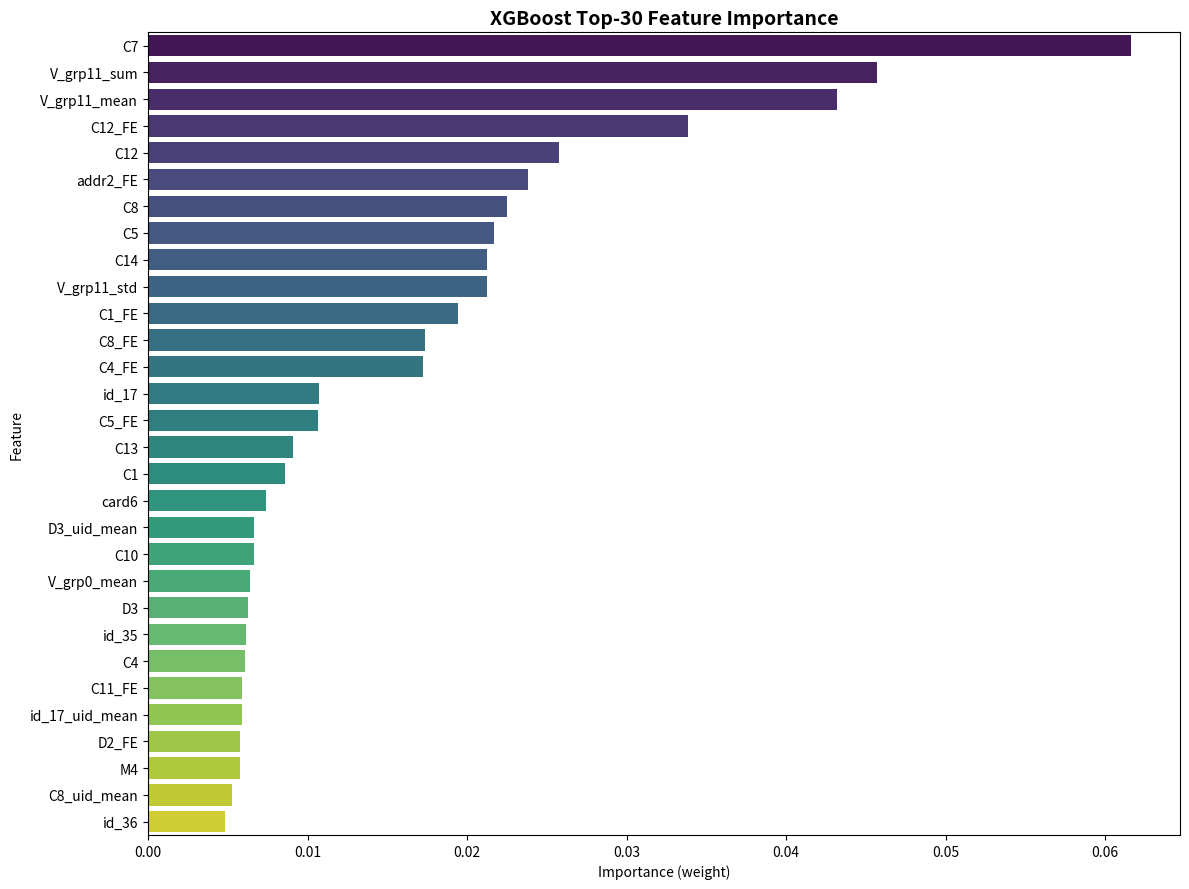

3771

In [ ]:
#XGBoost特征重要性（Top 30）— 使用与训练相同的优化参数
clf_final = xgb.XGBClassifier(
    n_estimators=2000,
    max_depth=9,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.5,
    min_child_weight=2,
    reg_alpha=0.05,
    reg_lambda=1.0,
    missing=-1,
    tree_method='hist',
    device='cuda',
    random_state=42,
)
clf_final.fit(X_train.loc[tr_idx, COLS], y_tr, verbose=False)

importance_df = pd.DataFrame({
    'Feature': COLS,
    'Importance': clf_final.feature_importances_
}).sort_values('Importance', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(12, 9))
sns.barplot(data=importance_df, x='Importance', y='Feature', ax=ax, palette='viridis')
ax.set_title('XGBoost Top-30 Feature Importance', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance (weight)')
plt.tight_layout()
plt.show()
del clf_final; gc.collect()

           三模型评估指标对比（验证集）
                       AUC      F1  Accuracy    RMSE
模型                                                  
LogisticRegression  0.8551  0.4101    0.9567  0.1953
SVM                 0.8318  0.1176    0.9593  0.1863
XGBoost             0.9650  0.6862    0.9789  0.1319


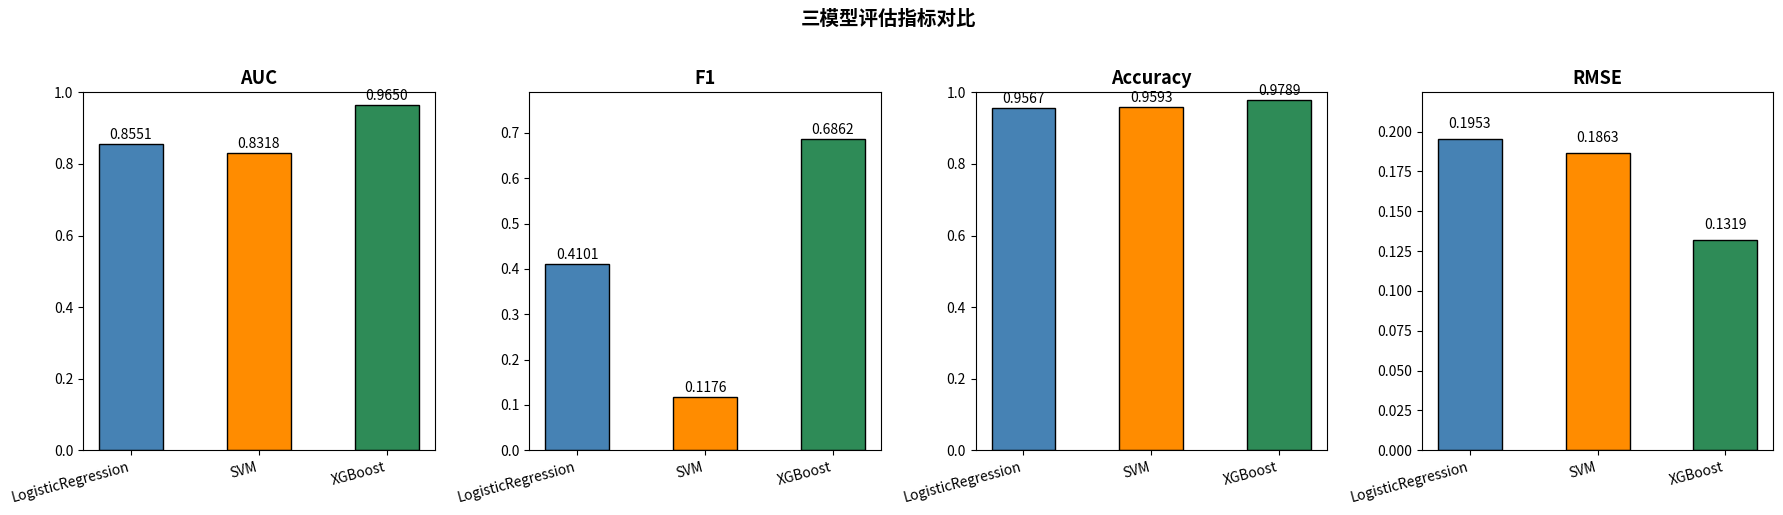

In [ ]:
#三模型对比汇总表
results_df = pd.DataFrame(results).T.round(4)
results_df.index.name = '模型'

print('=' * 58)
print('           三模型评估指标对比（验证集）')
print('=' * 58)
print(results_df.to_string())
print('=' * 58)

#可视化对比
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['AUC', 'F1', 'Accuracy', 'RMSE']
colors  = ['steelblue', 'darkorange', 'seagreen']
models  = results_df.index.tolist()

for ax, metric in zip(axes, metrics):
    vals = results_df[metric].values
    bars = ax.bar(models, vals, color=colors, edgecolor='black', width=0.5)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    ax.set_ylim(0, min(vals.max() * 1.15, 1.0))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10)
    ax.set_xticklabels(models, rotation=15, ha='right')

plt.suptitle('三模型评估指标对比', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 六、生成预测文件并提交Kaggle

In [ ]:
#使用XGBoost的GroupKFold集成预测结果生成提交文件
submission = pd.read_csv(DATA_PATH + 'sample_submission.csv', index_col='TransactionID')
submission['isFraud'] = test_preds
submission.to_csv('submission.csv')

print('提交文件已生成: submission.csv')
print(f'预测值分布:')
print(f'  均值:   {test_preds.mean():.6f}')
print(f'  最大值: {test_preds.max():.6f}')
print(f'  最小值: {test_preds.min():.6f}')
print(f'  预测为欺诈(>0.5)的比例: {(test_preds > 0.5).mean():.2%}')
submission.head(10)

提交文件已生成: submission.csv
预测值分布:
  均值:   0.025985
  最大值: 0.998185
  最小值: 0.000028
  预测为欺诈(>0.5)的比例: 1.71%


,isFraud
TransactionID,
3663549,0.000536
3663550,0.000470
3663551,0.001533
3663552,0.001163
3663553,0.000989
3663554,0.002086
3663555,0.010178
3663556,0.024374
3663557,0.000371


In [ ]:
#汇总所有关键输出到一个文本文件
lines = []
lines.append("=" * 60)
lines.append("IEEE-CIS 欺诈检测 - 完整运行结果汇总")
lines.append("=" * 60)

lines.append("\n【数据概况】")
lines.append(f"训练集: {X_train.shape[0]:,} 行 × {len(COLS)} 特征")
lines.append(f"测试集: {X_test.shape[0]:,} 行")
lines.append(f"欺诈比例: {y_train.mean():.4%}")

lines.append(f"\n【时序划分】")
lines.append(f"训练月份 (month < {val_month}): {len(tr_idx):,} 行")
lines.append(f"验证月份 (month = {val_month}): {len(val_idx):,} 行")
lines.append(f"训练集欺诈比例: {y_train.loc[tr_idx].mean():.4%}")
lines.append(f"验证集欺诈比例: {y_train.loc[val_idx].mean():.4%}")

lines.append(f"\n【特征工程】")
lines.append(f"V列处理: 339列原始V列 → {len(nan_groups)}个NaN分组 × 3聚合(sum/mean/std) = {len(group_feat_names)}列")
lines.append(f"最终特征数: {len(COLS)}")

lines.append(f"\n【三模型评估指标（验证集）】")
lines.append(results_df.to_string())

lines.append(f"\n【XGBoost GroupKFold OOF AUC】")
lines.append(f"{xgb_oof_auc:.4f}")

lines.append(f"\n【特征重要性 Top 20】")
lines.append(importance_df[['Feature', 'Importance']].head(20).to_string(index=False))

lines.append(f"\n【提交文件预测分布】")
lines.append(f"均值:   {test_preds.mean():.6f}")
lines.append(f"最大值: {test_preds.max():.6f}")
lines.append(f"最小值: {test_preds.min():.6f}")
lines.append(f"预测为欺诈(>0.5): {(test_preds > 0.5).mean():.2%}")

summary_text = "\n".join(lines)
print(summary_text)

with open('/kaggle/working/results_summary.txt', 'w', encoding='utf-8') as f:
    f.write(summary_text)
print("\n已保存到 results_summary.txt")

IEEE-CIS 欺诈检测 - 完整运行结果汇总

【数据概况】
训练集: 590,540 行 × 369 特征
测试集: 506,691 行
欺诈比例: 3.4990%

【时序划分】
训练月份 (month < 6): 582,429 行
验证月份 (month = 6): 8,111 行
训练集欺诈比例: 3.4895%
验证集欺诈比例: 4.1795%

【特征工程】
V列处理: 339列原始V列 → 15个NaN分组 × 3聚合(sum/mean/std) = 45列
最终特征数: 369

【三模型评估指标（验证集）】
                       AUC      F1  Accuracy    RMSE
模型                                                  
LogisticRegression  0.8551  0.4101    0.9567  0.1953
SVM                 0.8318  0.1176    0.9593  0.1863
XGBoost             0.9650  0.6862    0.9789  0.1319

【XGBoost GroupKFold OOF AUC】
0.9573

【特征重要性 Top 20】
     Feature  Importance
          C7    0.061605
 V_grp11_sum    0.045692
V_grp11_mean    0.043180
      C12_FE    0.033832
         C12    0.025738
    addr2_FE    0.023827
          C8    0.022505
          C5    0.021662
         C14    0.021225
 V_grp11_std    0.021217
       C1_FE    0.019417
       C8_FE    0.017368
       C4_FE    0.017214
       id_17    0.010740
       C5_FE    0.010646
         C13 